# **1. Perkenalan Dataset**


"The training file for the CHURN dataset contains a collection of 440882 customer records along with their respective features and churn labels. This file serves as the primary resource for training machine learning models to predict customer churn. Each record in the training file represents a customer and includes features such as age, gender, tenure, usage frequency, support calls, payment delay, subscription type, contract length, total spend, and last interaction. The churn label indicates whether the customer has churned (1) or not (0). By leveraging this training file, businesses can develop accurate churn prediction models to identify customers who are most likely to churn and take proactive actions to retain them."


-> https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset


# **2. Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# **3. Memuat Dataset**

In [2]:
# Membaca raw data (churn_raw)
df = pd.read_csv('../churn_raw.csv')
print(df.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

# **4. Exploratory Data Analysis (EDA)**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None

Jumlah data kosong:
 CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support 

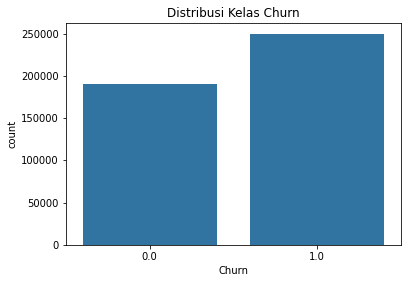

In [3]:
print(df.info())
print("\nJumlah data kosong:\n", df.isnull().sum())

plt.figure(figsize=(6, 4), dpi=72)

sns.countplot(x='Churn', data=df)
plt.title('Distribusi Kelas Churn')
plt.show()

# **5. Data Preprocessing**

In [4]:
df_clean = df.dropna().copy()
df_clean = df_clean.drop('CustomerID', axis=1)

# One-Hot Encoding
df_encoded = pd.get_dummies(
    df_clean, 
    columns=['Gender', 'Subscription Type', 'Contract Length'], 
    drop_first=True, 
    dtype=int
)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

df_preprocessed = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# Simpan dengan nama churn_preprocessing.csv
df_preprocessed.to_csv('churn_preprocessing.csv', index=False)
print("Data berhasil diproses!")

Data berhasil diproses!
